In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import time

In [2]:
##Load the Preprocessed Dataset
X_train = pd.read_csv("C:\\Users\\Admin\\Downloads\\Sentiment\\X_train.csv")
y_train = pd.read_csv("C:\\Users\\Admin\\Downloads\\Sentiment\\y_train.csv")

X_val = pd.read_csv("C:\\Users\\Admin\\Downloads\\Sentiment\\X_val.csv")
y_val = pd.read_csv("C:\\Users\\Admin\\Downloads\\Sentiment\\y_val.csv")

X_test = pd.read_csv("C:\\Users\\Admin\\Downloads\\Sentiment\\X_test.csv")
y_test = pd.read_csv("C:\\Users\\Admin\\Downloads\\Sentiment\\y_test.csv")


In [3]:
print(X_train.head(5))
print(y_train.value_counts())

                                               Tweet  \
0  @JustinTrudeau The truth of your evil becomes ...   
1  This cap is from the youngster's initial arres...   
2  "âFreedom Convoyâ organizer Tamara Lich â...   
3  Tamara Lich has been arrested.\n\n#FAFO #Freed...   
4  @JMeanypants While ppl in the Ukraine fight fo...   

                                       Cleaned_Tweet  \
0  the truth of your evil becomes more apparent e...   
1  this cap is from the youngster s initial arres...   
2  freedom convoy organizer tamara rich will be r...   
3   tamara lich has been arrested fafo freedomconvoy   
4  while pal in the ukraine fight for their real ...   

                                 Final_Cleaned_Tweet  
0  truth evil becomes apparent every day american...  
1  cap youngster initial arrest tan pant right ta...  
2  freedom convoy organizer tamara rich return ot...  
3              tamara lich arrest fafo freedomconvoy  
4  pal ukraine fight real freedom convoy forming ..

There is no class imbalance issue

#Changed from 5000 to 4000 to reduce training time 

In [33]:
# Initialize TF-IDF Vectorizer with unigram + bigram
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),        # Unigram + Bigram
    max_features=4000,         # Top 5000 features
    smooth_idf=True,           # Apply smoothing to avoid division by zero
    sublinear_tf=True          # Apply logarithmic term frequency scaling
)

Laplace smoothing is applied 

In [5]:
print(X_train['Final_Cleaned_Tweet'].isna().sum())
print(X_test['Final_Cleaned_Tweet'].isna().sum())
print(X_val['Final_Cleaned_Tweet'].isna().sum())


9
4
2


In [6]:
#Train
X_train['Final_Cleaned_Tweet'] = X_train['Final_Cleaned_Tweet'].fillna('').astype(str).str.strip()
train_mask = X_train['Final_Cleaned_Tweet'] != ''
X_train = X_train[train_mask]
y_train = y_train[train_mask]
#Val
X_val['Final_Cleaned_Tweet'] = X_val['Final_Cleaned_Tweet'].fillna('').astype(str).str.strip()
val_mask = X_val['Final_Cleaned_Tweet'] != ''
X_val = X_val[val_mask]
y_val = y_val[val_mask]
#Test
X_test['Final_Cleaned_Tweet'] = X_test['Final_Cleaned_Tweet'].fillna('').astype(str).str.strip()
test_mask = X_test['Final_Cleaned_Tweet'] != ''
X_test = X_test[test_mask]
y_test = y_test[test_mask]

In [7]:
# Fit on training data, transform train/val/test sets
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train['Final_Cleaned_Tweet'])
X_val_tfidf = tfidf_vectorizer.transform(X_val['Final_Cleaned_Tweet'])
X_test_tfidf = tfidf_vectorizer.transform(X_test['Final_Cleaned_Tweet'])

# Print shapes to verify
print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (26896, 4000)
Validation TF-IDF shape: (3998, 4000)
Test TF-IDF shape: (7496, 4000)


In [8]:
import pandas as pd

# Get feature names from the vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Convert the sparse matrix to a dense format and wrap in a DataFrame
df_tfidf_sample = pd.DataFrame(X_train_tfidf[:5].todense(), columns=feature_names)

# Display the DataFrame
print(df_tfidf_sample)

   1st  2020  2021  2022  2022 freedom  2022 fundraiser  2022 live  \
0  0.0   0.0   0.0   0.0           0.0              0.0        0.0   
1  0.0   0.0   0.0   0.0           0.0              0.0        0.0   
2  0.0   0.0   0.0   0.0           0.0              0.0        0.0   
3  0.0   0.0   0.0   0.0           0.0              0.0        0.0   
4  0.0   0.0   0.0   0.0           0.0              0.0        0.0   

   2022 ottawa  2022 police  2022 protest  ...  york  young  youtube   yr  \
0          0.0          0.0           0.0  ...   0.0    0.0      0.0  0.0   
1          0.0          0.0           0.0  ...   0.0    0.0      0.0  0.0   
2          0.0          0.0           0.0  ...   0.0    0.0      0.0  0.0   
3          0.0          0.0           0.0  ...   0.0    0.0      0.0  0.0   
4          0.0          0.0           0.0  ...   0.0    0.0      0.0  0.0   

   yup   ze  zealand  zero  zone   zu  
0  0.0  0.0      0.0   0.0   0.0  0.0  
1  0.0  0.0      0.0   0.0   0.0  0.

These features are a mixture of unigrams and bigrams — the top 5000 most important ones based on frequency and TF-IDF weight across X_train.

In [11]:
# Reshape for RNN input
num_features = X_train_tfidf.shape[1]
X_train_rnn = X_train_tfidf.toarray().reshape((X_train_tfidf.shape[0], num_features, 1))
X_val_rnn = X_val_tfidf.toarray().reshape((X_val_tfidf.shape[0], num_features, 1))
X_test_rnn = X_test_tfidf.toarray().reshape((X_test_tfidf.shape[0], num_features, 1))

# Encode labels
label_encoder = LabelEncoder()
y_train_enc = to_categorical(label_encoder.fit_transform(y_train))
y_val_enc = to_categorical(label_encoder.transform(y_val))
y_test_enc = to_categorical(label_encoder.transform(y_test))


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [12]:
print(y_train_enc)

[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]


In [13]:
#1. Check Shapes of Input and Labels
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_train_rnn shape:", X_train_rnn.shape)  # After reshape
print("y_train_enc shape:", y_train_enc.shape)


X_train_tfidf shape: (26896, 4000)
X_train_rnn shape: (26896, 4000, 1)
y_train_enc shape: (26896, 5)


In [14]:
#2. Check Sample Inputs and Labels
import numpy as np

print("Sample vector (flattened):", X_train_rnn[0].flatten()[:20])  # show first 20 features
print("Corresponding label (one-hot):", y_train_enc[0])

Sample vector (flattened): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Corresponding label (one-hot): [1. 0. 0. 0. 0.]


In [15]:
#No of samples have zero vector
import numpy as np

zero_rows = (X_train_tfidf.toarray().sum(axis=1) == 0).sum()
print(f"Samples with all-zero vectors: {zero_rows} / {X_train_tfidf.shape[0]}")


Samples with all-zero vectors: 17 / 26896


In [16]:
duplicates = X_train.duplicated().sum()
print("Duplicate input rows:", duplicates)

Duplicate input rows: 0


In [17]:
empty_count = (X_train['Final_Cleaned_Tweet'].str.strip() == '').sum()
print("Empty tweets:", empty_count)

Empty tweets: 0


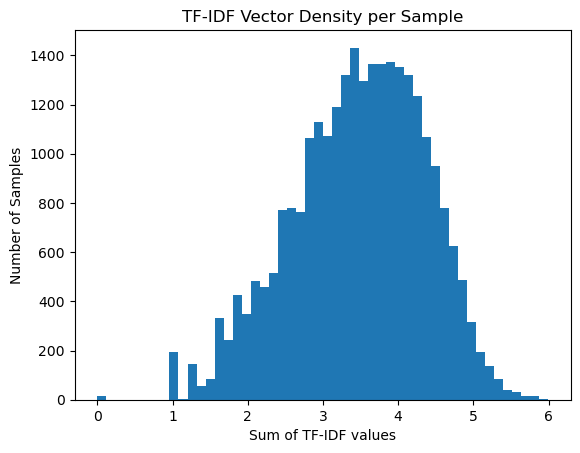

In [20]:
import matplotlib.pyplot as plt

row_sums = X_train_tfidf.toarray().sum(axis=1)
plt.hist(row_sums, bins=50)
plt.title("TF-IDF Vector Density per Sample")
plt.xlabel("Sum of TF-IDF values")
plt.ylabel("Number of Samples")
plt.show()


don’t have excessive sparsity — most tweets are meaningful in TF-IDF space

In [18]:
# Top 20 tokens with highest IDF
idf_scores = dict(zip(tfidf_vectorizer.get_feature_names_out(), tfidf_vectorizer.idf_))
top_idf = sorted(idf_scores.items(), key=lambda x: x[1], reverse=True)[:20]
print("Top rarest terms by IDF:", top_idf)


Top rarest terms by IDF: [('blah', 9.408010565979025), ('amp quit', 8.801874762408708), ('amp ape', 8.560712705591822), ('ci', 8.560712705591822), ('knock', 8.560712705591822), ('syrian', 8.560712705591822), ('wellington street', 8.560712705591822), ('ze', 8.560712705591822), ('camioneros', 8.49171983410487), ('dat', 8.49171983410487), ('palazzo', 8.49171983410487), ('pig', 8.49171983410487), ('pillow', 8.49171983410487), ('tag', 8.49171983410487), ('withdraw', 8.49171983410487), ('yr', 8.49171983410487), ('3rd', 8.4271813129673), ('allegation', 8.4271813129673), ('avec', 8.4271813129673), ('bauer', 8.4271813129673)]


In [19]:
print("Final train input shape:", X_train_rnn.shape)
print("Final train label shape:", y_train_enc.shape)

print("Final val input shape:", X_val_rnn.shape)
print("Final val label shape:", y_val_enc.shape)


Final train input shape: (26896, 4000, 1)
Final train label shape: (26896, 5)
Final val input shape: (3998, 4000, 1)
Final val label shape: (3998, 5)


In [38]:
# Build the model
model = Sequential([
    SimpleRNN(64, input_shape=(num_features, 1), activation='tanh'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(y_train_enc.shape[1], activation='softmax')
])

# Compile & train
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


#view the model configuration
model.summary()


start_time = time.time()
history = model.fit(
    X_train_rnn, y_train_enc,
    validation_data=(X_val_rnn, y_val_enc),
    epochs=10,
    batch_size=64,
    verbose=1
)
end_time = time.time()
print("Train Time =", round(end_time - start_time, 2), "seconds")

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,469 (25.27 KB)

 Trainable params: 6,469 (25.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 182s 423ms/step - accuracy: 0.1971 - loss: 1.6355 - val_accuracy: 0.0738 - val_loss: 1.6094
Epoch 2/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 186s 441ms/step - accuracy: 0.2028 - loss: 1.6105 - val_accuracy: 0.0958 - val_loss: 1.6087
Epoch 3/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 188s 447ms/step - accuracy: 0.2025 - loss: 1.6098 - val_accuracy: 0.1721 - val_loss: 1.6129
Epoch 4/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 195s 462ms/step - accuracy: 0.2008 - loss: 1.6097 - val_accuracy: 0.1483 - val_loss: 1.6075
Epoch 5/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 193s 458ms/step - accuracy: 0.1990 - loss: 1.6095 - val_accuracy: 0.0958 - val_loss: 1.6095
Epoch 6/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 190s 452ms/step - accuracy: 0.1971 - loss: 1.6096 - val_accuracy: 0.0958 - val_loss: 1.6112
Epoch 7/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 191s 453ms/step - accuracy: 0.1978 - loss: 1.6096 - val_accuracy: 0.1483 - val_loss: 1.6095
Epoch 8/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 190s 451ms/step - accuracy: 0.1979 -

841/841 ━━━━━━━━━━━━━━━━━━━━ 111s 132ms/step

 Training Set Accuracy: 0.2

 Training Classification Report:
              precision    recall  f1-score   support

    Mild_Neg       0.20      1.00      0.33      5380
    Mild_Pos       0.00      0.00      0.00      5379
     Neutral       0.00      0.00      0.00      5376
  Strong_Neg       0.00      0.00      0.00      5380
  Strong_Pos       0.00      0.00      0.00      5381

    accuracy                           0.20     26896
   macro avg       0.04      0.20      0.07     26896
weighted avg       0.04      0.20      0.07     26896

F1 Score (Positive): 0.0
F1 Score (Negative): 0.0


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packag

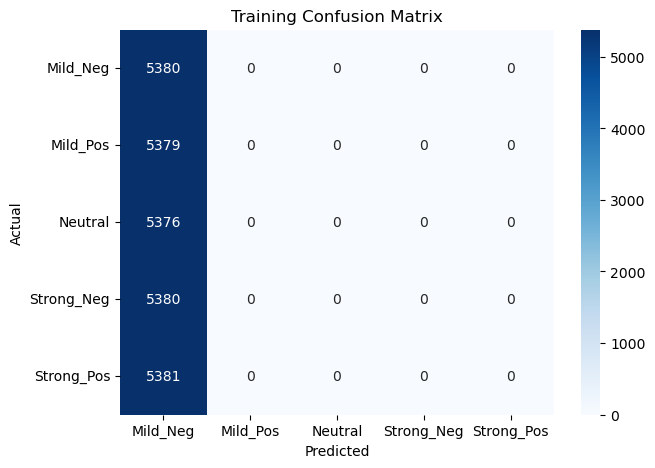

Training AUC Score: 0.5
235/235 ━━━━━━━━━━━━━━━━━━━━ 31s 132ms/step

 Testing Set Accuracy: 0.0795

 Testing Classification Report:
              precision    recall  f1-score   support

    Mild_Neg       0.08      1.00      0.15       596
    Mild_Pos       0.00      0.00      0.00      1069
     Neutral       0.00      0.00      0.00      1226
  Strong_Neg       0.00      0.00      0.00       718
  Strong_Pos       0.00      0.00      0.00      3887

    accuracy                           0.08      7496
   macro avg       0.02      0.20      0.03      7496
weighted avg       0.01      0.08      0.01      7496

F1 Score (Positive): 0.0
F1 Score (Negative): 0.0


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packag

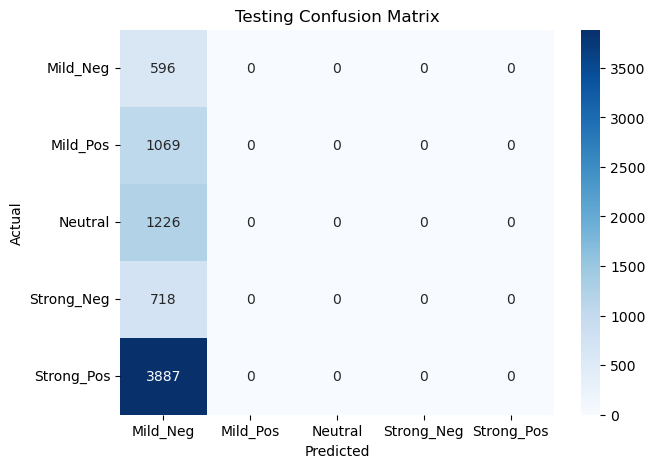

Testing AUC Score: 0.5


In [39]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function to evaluate any set
def evaluate_model(X, y_true_enc, dataset_name="Test"):
    y_probs = model.predict(X)
    y_pred = np.argmax(y_probs, axis=1)
    y_true = np.argmax(y_true_enc, axis=1)

    accuracy = accuracy_score(y_true, y_pred)
    print(f"\n {dataset_name} Set Accuracy: {round(accuracy, 4)}")

    report = classification_report(y_true, y_pred, target_names=label_encoder.classes_)
    print(f"\n {dataset_name} Classification Report:\n{report}")

    # F1 Scores
    report_dict = classification_report(y_true, y_pred, target_names=label_encoder.classes_, output_dict=True)
    f1_pos = report_dict.get("Strong_Pos", {}).get("f1-score", "N/A")
    f1_neg = report_dict.get("Strong_Neg", {}).get("f1-score", "N/A")
    print(f"F1 Score (Positive): {f1_pos}")
    print(f"F1 Score (Negative): {f1_neg}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"{dataset_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # AUC Score
    try:
        auc = roc_auc_score(y_true_enc, y_probs, multi_class='ovr')
        print(f"{dataset_name} AUC Score: {round(auc, 4)}")
    except:
        print(f"AUC for {dataset_name} could not be calculated (possible class prediction issue).")

# Run evaluation
evaluate_model(X_train_rnn, y_train_enc, dataset_name="Training")
evaluate_model(X_test_rnn, y_test_enc, dataset_name="Testing")


Only One Class Being Learned (Mild_Pos)
Precision/Recall for all other classes = 0.
The model predicts Mild_Pos 93% of the time regardless of input.

Severe model underfitting is likely.
TF-IDF doesn't retain sequence info. RNNs learn from time steps — so a (num_features, 1) view of TF-IDF is meaningless.


235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step


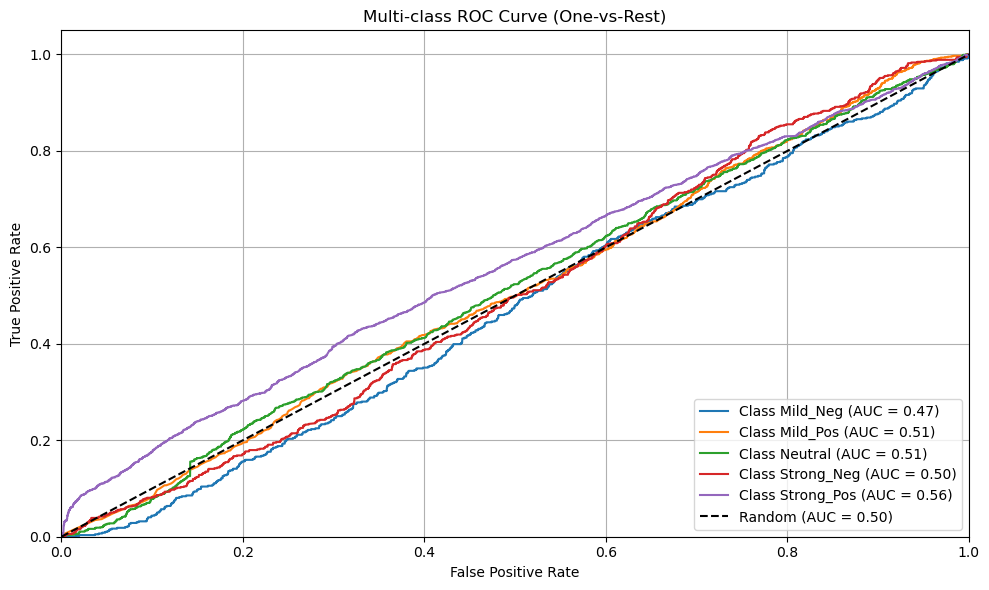

In [24]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Predict probabilities
y_pred_prob = model.predict(X_test_rnn)  # shape: (n_samples, n_classes)
# Class names (edit this if needed)
class_names = ['Mild_Neg', 'Mild_Pos', 'Neutral', 'Strong_Neg', 'Strong_Pos']

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_enc.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_enc[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()


All AUC values are very close to 0.50, which means your model is not distinguishing between the classes.



In [28]:
#VExtract Feature Weights
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Step 1: Initialize and fit TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train['Final_Cleaned_Tweet'])

# Step 2: Get feature names and mean TF-IDF scores
feature_names = tfidf_vectorizer.get_feature_names_out()
avg_weights = np.asarray(X_train_tfidf.mean(axis=0)).flatten()

# Step 3: Get top 2 features with highest average weights
top_indices = avg_weights.argsort()[-2:][::-1]
top_features = [(feature_names[i], avg_weights[i]) for i in top_indices]

# Step 4: Print them
print("Feature weightages added")
print("Top 2 features with highest average TF-IDF weights:")
for name, score in top_features:
    print(f"  - {name}: {round(score, 4)}")




Feature weightages added
Top 2 features with highest average TF-IDF weights:
  - freedom: 0.0498
  - convoy: 0.0489


In [29]:
model.save('my_model_rnn.keras')

Model 2 : Added Batch normalization 

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, BatchNormalization


model = Sequential([
    SimpleRNN(64,activation='tanh', return_sequences=True, input_shape=(X_train_rnn.shape[1], 1)),
    BatchNormalization(),
    Dropout(0.3),

    SimpleRNN(32),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(y_train_enc.shape[1], activation='softmax')
])


C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
from tensorflow.keras.callbacks import EarlyStopping
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Early stopping: monitor val_loss and restore best weights
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)
start_time = time.time()
history = model.fit(
    X_train_rnn, y_train_enc,
    validation_data=(X_val_rnn, y_val_enc),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

end_time = time.time()
print("Train Time =", round(end_time - start_time, 2), "seconds")

Epoch 1/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 916s 2s/step - accuracy: 0.2034 - loss: 1.7694 - val_accuracy: 0.5100 - val_loss: 1.3987
Epoch 2/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 900s 2s/step - accuracy: 0.2038 - loss: 1.6235 - val_accuracy: 0.5098 - val_loss: 1.4482
Epoch 3/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 923s 2s/step - accuracy: 0.2086 - loss: 1.6140 - val_accuracy: 0.5100 - val_loss: 1.4731
Epoch 4/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 902s 2s/step - accuracy: 0.2113 - loss: 1.6096 - val_accuracy: 0.5100 - val_loss: 1.3917
Epoch 5/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 899s 2s/step - accuracy: 0.2163 - loss: 1.6056 - val_accuracy: 0.5100 - val_loss: 1.3888
Epoch 6/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 891s 2s/step - accuracy: 0.2105 - loss: 1.6042 - val_accuracy: 0.5100 - val_loss: 1.5460
Epoch 7/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 1042s 2s/step - accuracy: 0.2053 - loss: 1.6043 - val_accuracy: 0.2126 - val_loss: 1.5795
Epoch 8/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 975s 2s/step - accuracy: 0.2137 - loss: 1.6033 - val_acc

In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 4000, 64)       │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,417 (103.20 KB)

 Trainable params: 8,741 (34.14 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 17,484 (68.30 KB)

841/841 ━━━━━━━━━━━━━━━━━━━━ 255s 302ms/step

 Training Set Accuracy: 0.2001

 Training Classification Report:
              precision    recall  f1-score   support

    Mild_Neg       0.00      0.00      0.00      5380
    Mild_Pos       0.00      0.00      0.00      5379
     Neutral       0.00      0.00      0.00      5376
  Strong_Neg       0.00      0.00      0.00      5380
  Strong_Pos       0.20      1.00      0.33      5381

    accuracy                           0.20     26896
   macro avg       0.04      0.20      0.07     26896
weighted avg       0.04      0.20      0.07     26896

F1 Score (Strong_Pos): 0.33342627877435943
F1 Score (Strong_Neg): 0.0


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packag

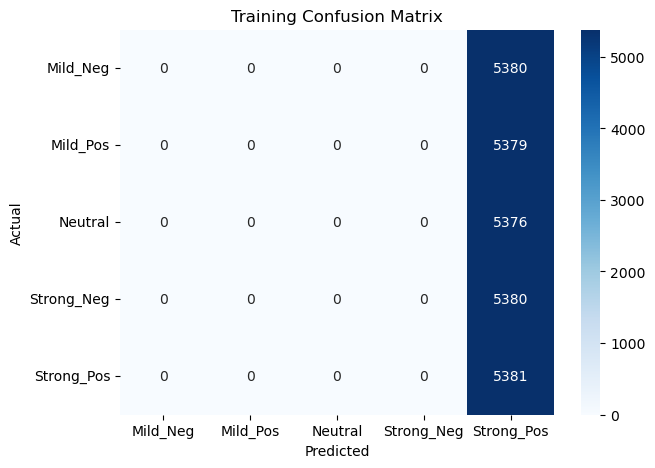

Training AUC Score: 0.497
235/235 ━━━━━━━━━━━━━━━━━━━━ 73s 309ms/step 

 Testing Set Accuracy: 0.5185

 Testing Classification Report:
              precision    recall  f1-score   support

    Mild_Neg       0.00      0.00      0.00       596
    Mild_Pos       0.00      0.00      0.00      1069
     Neutral       0.00      0.00      0.00      1226
  Strong_Neg       0.00      0.00      0.00       718
  Strong_Pos       0.52      1.00      0.68      3887

    accuracy                           0.52      7496
   macro avg       0.10      0.20      0.14      7496
weighted avg       0.27      0.52      0.35      7496

F1 Score (Strong_Pos): 0.6829482561714838
F1 Score (Strong_Neg): 0.0


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packag

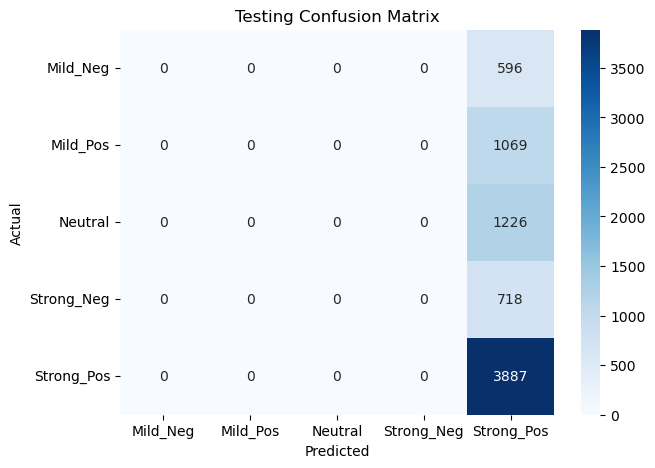

Testing AUC Score: 0.4955


In [35]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function to evaluate any set
def evaluate_model(X, y_true_enc, dataset_name="Test"):
    y_probs = model.predict(X)
    y_pred = np.argmax(y_probs, axis=1)
    y_true = np.argmax(y_true_enc, axis=1)

    accuracy = accuracy_score(y_true, y_pred)
    print(f"\n {dataset_name} Set Accuracy: {round(accuracy, 4)}")

    report = classification_report(y_true, y_pred, target_names=label_encoder.classes_)
    print(f"\n {dataset_name} Classification Report:\n{report}")

    # F1 Scores
    report_dict = classification_report(y_true, y_pred, target_names=label_encoder.classes_, output_dict=True)
    f1_pos = report_dict.get("Strong_Pos", {}).get("f1-score", "N/A")
    f1_neg = report_dict.get("Strong_Neg", {}).get("f1-score", "N/A")
    print(f"F1 Score (Strong_Pos): {f1_pos}")
    print(f"F1 Score (Strong_Neg): {f1_neg}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"{dataset_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # AUC Score
    try:
        auc = roc_auc_score(y_true_enc, y_probs, multi_class='ovr')
        print(f"{dataset_name} AUC Score: {round(auc, 4)}")
    except:
        print(f"AUC for {dataset_name} could not be calculated (possible class prediction issue).")

# Run evaluation
evaluate_model(X_train_rnn, y_train_enc, dataset_name="Training")
evaluate_model(X_test_rnn, y_test_enc, dataset_name="Testing")


235/235 ━━━━━━━━━━━━━━━━━━━━ 63s 267ms/step


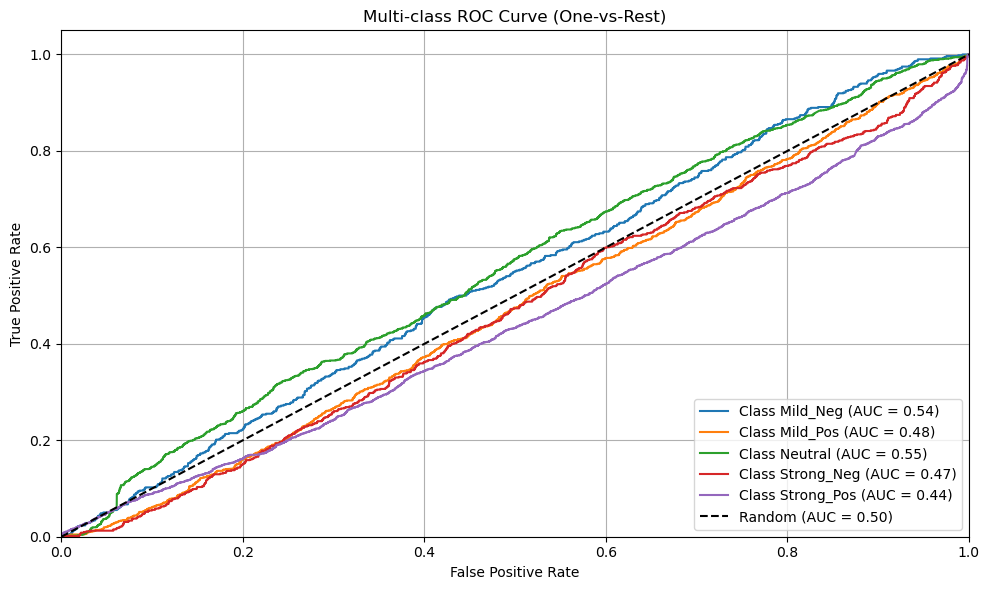

In [37]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Predict probabilities
y_pred_prob = model.predict(X_test_rnn)  # shape: (n_samples, n_classes)
# Class names (edit this if needed)
class_names = ['Mild_Neg', 'Mild_Pos', 'Neutral', 'Strong_Neg', 'Strong_Pos']

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_enc.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_enc[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()


Despite improving the model architecture (BatchNorm, Dropout, EarlyStopping) there was no improvement in the model performance but slight changes like the F1 score can improved for positive class from 0 to 0.68 

In [36]:
model.save("my_model_RNN.keras")